### The Hebbian and Anti-Hebbian Neural Network, 2 layers

The new network will have two parts:
- In their first layer, the neurons will be connected with a weight matrix \( W \) between output neurons \( y \) and input neurons \( x \).
$$
\mathbf{y = Wx \in \mathbb{R}^m}
$$
- In their second layer, the output neurons \( y \) will conduct inhibition using between each other with a weight matrix \( V \).
$$
\mathbf{y = Wx + Vy \in \mathbb{R}^m}
$$

The first layer is a Hebbian network, while the second layer is an Anti-Hebbian network.
The equation to update the weights $\mathbf{W}$ is the same as the Hebbian network, while the equation to update the weights $\mathbf{V}$ is the same as the Anti-Hebbian network.

For symmetric, Oja's rule setting:
$$
\mathbf{\Delta W = \eta (yx^T - y^2 W)}
$$

$$
\mathbf{\Delta V = - \gamma (yy^T)}
$$

For asymmetric, Sanger's rule setting:
$$
\mathbf{\Delta W = \eta (yx^T - y^2 W)}
$$

$$
\mathbf{\Delta V = \gamma (yy^T - y^2 V_B), V_B = tril(V)}
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hebbian.models import HebbianModel, OjaNetwork, SangerNetwork
from typing import Any, Optional
import pandas as pd

### Model structure

In [ ]:
class antiHebbianModel(HebbianModel):
    """
    Two-layer Hebbian / anti-Hebbian network with optional activity-dependent lateral learning.
    """
    def __init__(self, output_size: int, learning_rate: float = 0.01, learning_rate2: Optional[float] = None, input_size: int = None, rng: Optional[Any] = None) -> None:
        super().__init__(output_size, learning_rate, learning_rate2, input_size, rng)
    

### Test case 2D

In [3]:
from hebbian.utils import generate_covariance_matrix, instantiate_samples_by_cov, plot_samples_and_top2_pcs
N = 2
m = 2
n_samples = 10001
X_seed = 0
# get /sigma
eigenvalues = np.array([10.0, 0.8])  # Your desired eigenvalues

# eigenvalues = np.array([12.0, 5.0, 3.0, 1.8, 1.0, 0.3, 0.1, 0.05])  # Your desired eigenvalues
Sigma = generate_covariance_matrix(dim=m, eigenvalues=eigenvalues, method="eigenvalues")

samples_2d = instantiate_samples_by_cov(Sigma, N, m, seed=X_seed, n_samples=n_samples)

# hebbian strength
learning_rate = 0.02
learning_rate2 = 0.1
# eps_w 
eps_w = 0.01
eps_v = 0.1

{'pcs': array([[ 0.88176846, -0.47168251],
        [-0.47168251, -0.88176846]]),
 'eigvals': array([9.89945325, 0.79536663]),
 'mean': array([-0.0137095 ,  0.01144277])}

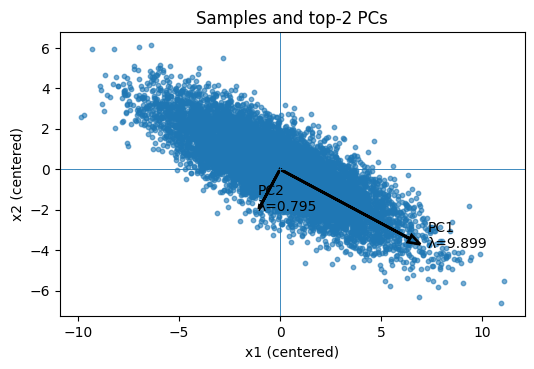

In [4]:
# generate 2D input data

plot_samples_and_top2_pcs(samples_2d)

In [ ]:
from hebbian.utils import Y_aligned_training_testing_online, training_testing


### Testing alignment to the first PC, applying to all output neurons.

run  1
step    0 | order = [0 1] | best|corr|= [0.992 0.344]
step 1000 | order = [1 0] | best|corr|= [0.9 0.9]
step 2000 | order = [1 0] | best|corr|= [0.9 0.9]
step 3000 | order = [1 0] | best|corr|= [0.9 0.9]
step 4000 | order = [1 0] | best|corr|= [0.9 0.9]
step 5000 | order = [1 0] | best|corr|= [0.9 0.9]
step 6000 | order = [1 0] | best|corr|= [0.9 0.9]
step 7000 | order = [1 0] | best|corr|= [0.9 0.9]
step 8000 | order = [1 0] | best|corr|= [0.9 0.9]
step 9000 | order = [1 0] | best|corr|= [0.9 0.9]
step 10000 | order = [1 0] | best|corr|= [0.9 0.9]


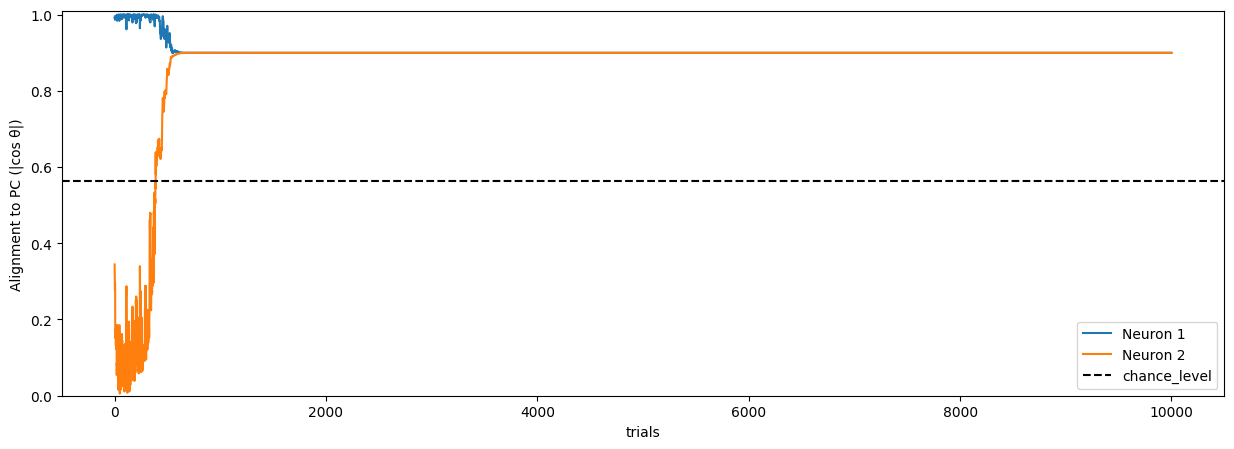

run  2
step    0 | order = [1 0] | best|corr|= [0.969 0.623]
step 1000 | order = [1 0] | best|corr|= [0.999 0.999]
step 2000 | order = [1 0] | best|corr|= [0.999 0.999]
step 3000 | order = [1 0] | best|corr|= [0.999 0.999]
step 4000 | order = [1 0] | best|corr|= [0.999 0.999]
step 5000 | order = [1 0] | best|corr|= [0.999 0.999]
step 6000 | order = [1 0] | best|corr|= [0.999 0.999]
step 7000 | order = [1 0] | best|corr|= [0.999 0.999]
step 8000 | order = [1 0] | best|corr|= [0.999 0.999]
step 9000 | order = [1 0] | best|corr|= [0.999 0.999]
step 10000 | order = [1 0] | best|corr|= [0.999 0.999]


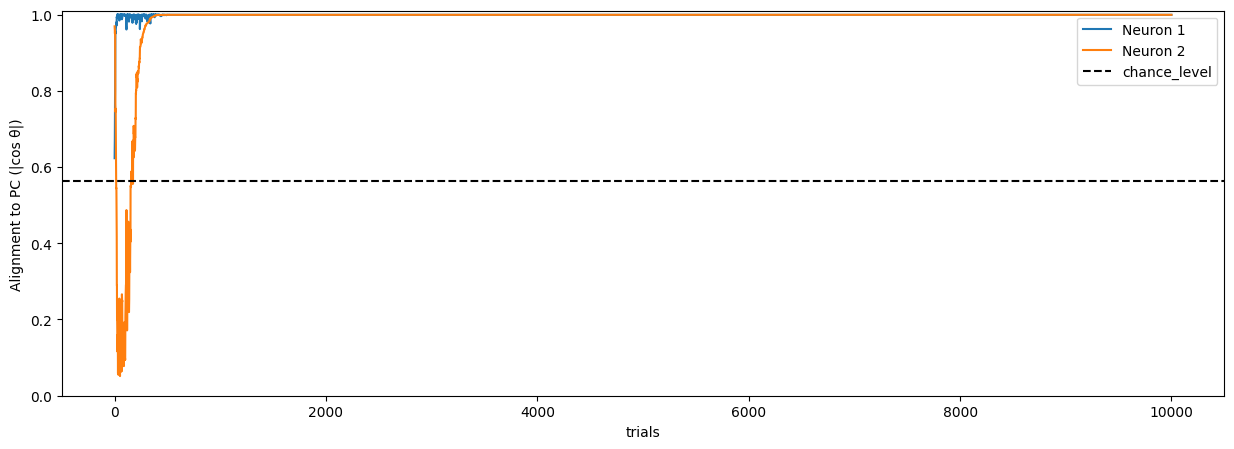

<Figure size 640x480 with 0 Axes>

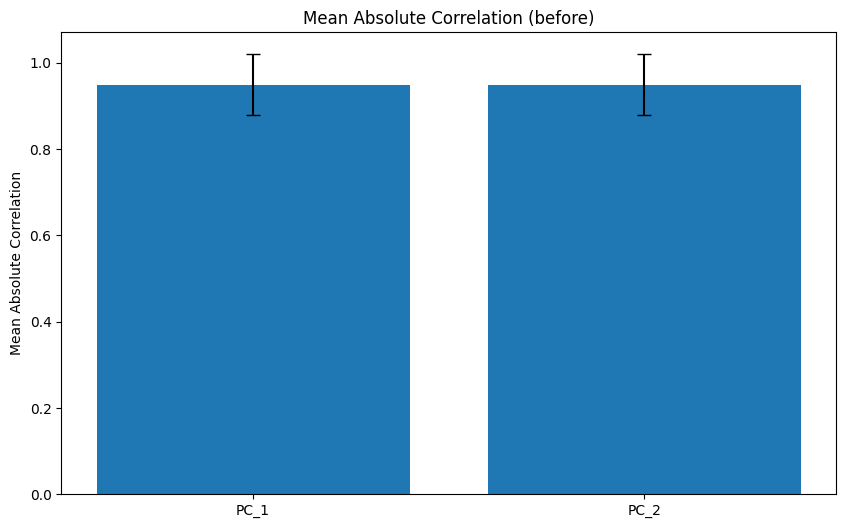

In [12]:
model1 = OjaNetwork(input_size=2, output_size=2, learning_rate=learning_rate)
model2 = SangerNetwork(input_size=2, output_size=2, learning_rate=learning_rate)

training_testing(model1, samples_2d, m, runs=2)

In [ ]:
model = antiHebbianModel(input_size=2, output_size=2, learning_rate=learning_rate, 
                         learning_rate2= learning_rate2, 
                         eps_w=eps_w, eps_v = eps_v)

### Test case 3D

In [13]:
N = 3
m = 3
n_samples = 10001
X_seed = 0
# get /sigma
eigenvalues = np.array([10.0, 4.0, 0.8])  # Your desired eigenvalues

# eigenvalues = np.array([12.0, 5.0, 3.0, 1.8, 1.0, 0.3, 0.1, 0.05])  # Your desired eigenvalues
Sigma = generate_covariance_matrix(dim=m, eigenvalues=eigenvalues, method="eigenvalues")

samples_3d = instantiate_samples_by_cov(Sigma, N, m, seed=X_seed, n_samples=n_samples)


In [15]:
model = antiHebbianModel(input_size=3, output_size=3, learning_rate=learning_rate, 
                         learning_rate2= learning_rate2, 
                         eps_w=eps_w, eps_v = eps_v)


training_testing(model, samples_3d, m, runs=2)

run  1
step    0 | order = [0 1 2] | best|corr|= [0.143 0.947 0.773]


/Users/yat-lok/miniconda3/envs/nn/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2792: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/var/folders/7_/28s2yvwn3q7dgbxbz546rc180000gn/T/ipykernel_66021/1279322182.py:60: RuntimeWarning: overflow encountered in matmul
  y_new = Wx + self.V @ y
/var/folders/7_/28s2yvwn3q7dgbxbz546rc180000gn/T/ipykernel_66021/1279322182.py:60: RuntimeWarning: invalid value encountered in matmul
  y_new = Wx + self.V @ y


ValueError: matrix contains invalid numeric entries

### Test case 10D

In [ ]:
from hebbian.utils import generate_covariance_matrix

In [ ]:
N = 100
m = 10
n_samples = 10001
X_seed = 0
# get /sigma
eigenvalues = np.array([20., 15., 10.0, 8, 4.0, 0.8, 0.5, 0.3, 0.1, 0.05])  # Your desired eigenvalues

# eigenvalues = np.array([12.0, 5.0, 3.0, 1.8, 1.0, 0.3, 0.1, 0.05])  # Your desired eigenvalues
Sigma = generate_covariance_matrix(dim=m, eigenvalues=eigenvalues, method="eigenvalues")

samples_10d = instantiate_samples_by_cov(Sigma, N, m, seed=X_seed, n_samples=n_samples)

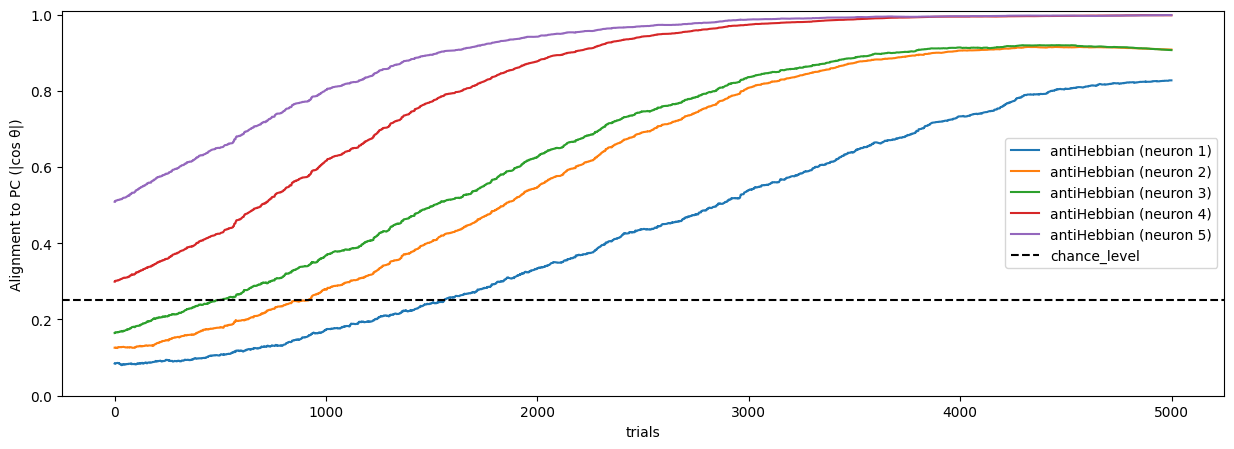

In [ ]:
model = antiHebbianModel(input_size = 100, output_size=10, learning_rate=learning_rate, 
                         learning_rate2= learning_rate2, 
                         eps_w=-eps_w, eps_v=eps_v)